# Medical Retrieval-Augmented Generation (RAG) — PubMedBERT + GPT-2, on MedQuAD

**Part 1** builds a baseline medical RAG pipeline from scratch with open-source models:

| Stage | Component | Model | Role |
|---|---|---|---|
| **R**etrieve | Bi-encoder | `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext` | Turns medical Q/A text into semantic vectors |
| — | Vector search | `faiss-cpu` | Finds the most similar Q/A pairs fast |
| **A**ugment | Prompt builder | — | Stitches retrieved Q/A pairs into a prompt |
| **G**enerate | Causal LM | `gpt2` | Writes the final answer grounded in the retrieved context |

**Part 2** upgrades every stage: a retrieval-tuned PubMedBERT embedding model, answer chunking, a cross-encoder re-ranker, a scalable FAISS index, and a larger GPT-2 generator.

**Real data**: the **MedQuAD** dataset (medical question/answer pairs sourced from NIH sites), loaded from a **CSV file** (`medquad.csv`).

> **How to run**: Runtime → Change runtime type → T4 GPU (recommended, but CPU also works), then Runtime → Run all.
>
> **Note on GPT-2**: `gpt2` is a general-purpose, *not* instruction-tuned language model. It can still produce grounded answers when the retrieved context does most of the work, but expect less polished output than an instruction-tuned model like Flan-T5. Swap in `gpt2-medium`/`gpt2-large`, or any other open causal LM, if you want stronger answers — see Step 12.

## Step 1 — Install dependencies

- `transformers` → PubMedBERT, GPT-2
- `sentence-transformers` → retrieval-tuned biomedical bi-encoder + cross-encoder re-ranker (Part 2)
- `datasets` → optional automatic download of MedQuAD if you don't have `medquad.csv` locally
- `pandas` → reading the MedQuAD CSV
- `faiss-cpu` → vector similarity search
- `torch` / `accelerate` → deep learning backend

In [10]:
!pip install -q transformers sentence-transformers datasets faiss-cpu torch accelerate pandas

## Step 2 — Imports and device setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [12]:
import os
import torch
import faiss
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer, CrossEncoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Step 3 — Load real data: MedQuAD from a CSV file

[MedQuAD](https://github.com/abachaa/MedQuAD) is a public dataset of real medical question/answer pairs curated from NIH websites (NIAMS, GARD, MedlinePlus, etc.).

This cell expects a **`medquad.csv`** file with (at least) `Question` and `Answer` columns:

- **If you already have `medquad.csv`** — upload it to the Colab file browser (left sidebar) before running this cell, or set `CSV_PATH` below to its location (e.g. a path in Google Drive).
- **If you don't have it yet** — the cell will try to download the MedQuAD data via the Hugging Face `datasets` library and save it locally as `medquad.csv`, so everything downstream still reads from a real CSV file.
- **If that automatic download fails** (e.g. no internet in your environment) — it falls back to an upload prompt.

In [13]:
CSV_PATH = "/content/medquad.csv"  # <-- change this if your CSV lives somewhere else (e.g. "/content/drive/MyDrive/medquad.csv")

if not os.path.exists(CSV_PATH):
    print(f"'{CSV_PATH}' not found locally — trying to fetch MedQuAD via Hugging Face datasets...")
    try:
        from datasets import load_dataset
        hf_ds = load_dataset("lavita/MedQuAD", split="train")
        df_dl = hf_ds.to_pandas()
        df_dl.to_csv(CSV_PATH, index=False)
        print(f"Downloaded MedQuAD and saved it to '{CSV_PATH}' ({len(df_dl)} rows)")
    except Exception as e:
        print("Automatic download failed:", repr(e))
        try:
            from google.colab import files
            print("Please upload your medquad.csv file now...")
            uploaded = files.upload()
            CSV_PATH = list(uploaded.keys())[0]
        except ImportError:
            raise FileNotFoundError(
                "Could not find or download medquad.csv. Please place a MedQuAD CSV "
                "file (with Question/Answer columns) at CSV_PATH and re-run this cell."
            )

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from '{CSV_PATH}'")
print("Columns:", list(df.columns))
df.head()

Loaded 16412 rows from '/content/medquad.csv'
Columns: ['question', 'answer', 'source', 'focus_area']


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


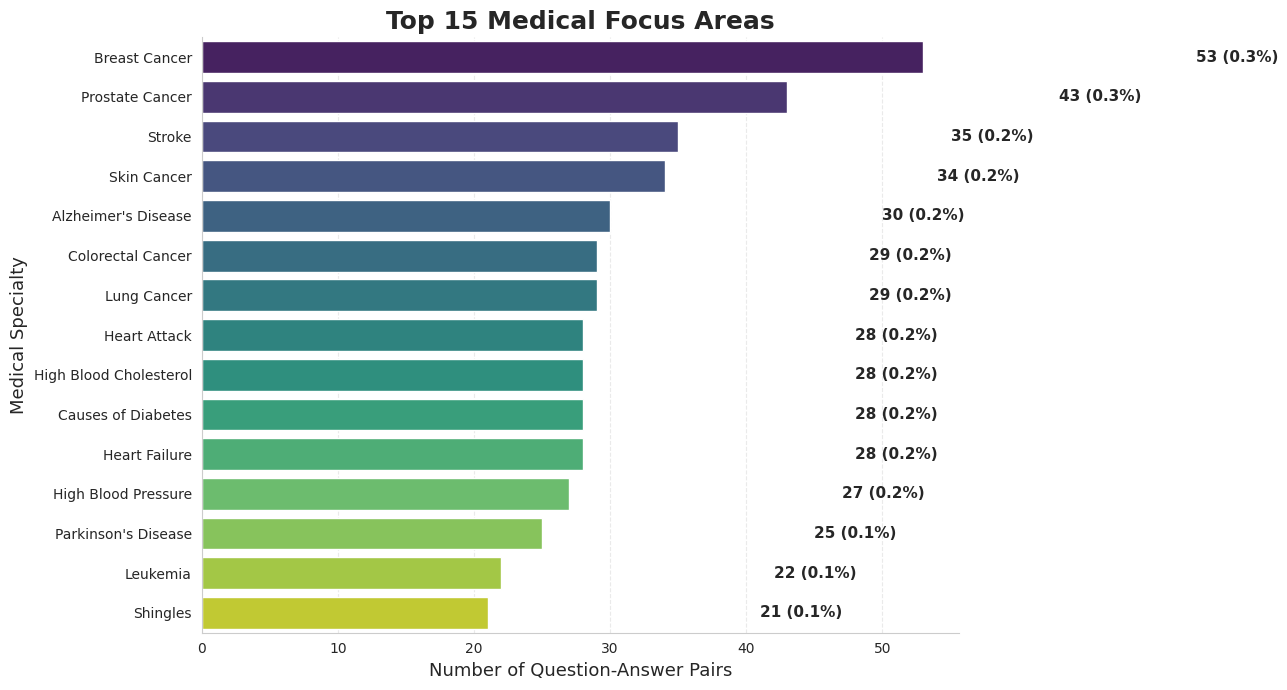

FOCUS AREA SUMMARY
Total Samples        : 16,412
Unique Focus Areas   : 5,126
Most Common Area     : Breast Cancer
Largest Category     : 53 samples
Smallest Category    : 1 samples

Top 10 Distribution


,Focus Area,Count,Percentage,Cumulative %
0,Breast Cancer,53,0.32,0.32
1,Prostate Cancer,43,0.26,0.58
2,Stroke,35,0.21,0.79
3,Skin Cancer,34,0.21,1.00
4,Alzheimer's Disease,30,0.18,1.18
5,Colorectal Cancer,29,0.18,1.36
6,Lung Cancer,29,0.18,1.54
7,Heart Attack,28,0.17,1.71
8,High Blood Cholesterol,28,0.17,1.88
9,Causes of Diabetes,28,0.17,2.05



Top 15 categories cover 2.79% of the dataset.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Count categories
focus_counts = (
    df["focus_area"]
    .fillna("Unknown")
    .value_counts()
)

# Top N categories
TOP_N = 15
top_focus = focus_counts.head(TOP_N)

# Percentage
focus_percent = (top_focus / len(df) * 100).round(2)

# Plot DataFrame
plot_df = (
    top_focus
    .reset_index()
    .rename(columns={"focus_area":"Focus Area","count":"Count"})
)

plot_df["Percentage"] = focus_percent.values
plot_df["Cumulative %"] = plot_df["Percentage"].cumsum().round(2)

# ------------------------------------
# Plot
# ------------------------------------

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=plot_df,
    y="Focus Area",
    x="Count",
    palette="viridis"
)

# Value labels
for i, row in plot_df.iterrows():
    ax.text(
        row["Count"] + 20,
        i,
        f'{row["Count"]:,} ({row["Percentage"]:.1f}%)',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    f"Top {TOP_N} Medical Focus Areas",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Question-Answer Pairs", fontsize=13)
plt.ylabel("Medical Specialty", fontsize=13)

plt.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

# ------------------------------------
# Summary Statistics
# ------------------------------------

print("="*70)
print("FOCUS AREA SUMMARY")
print("="*70)

print(f"Total Samples        : {len(df):,}")
print(f"Unique Focus Areas   : {df['focus_area'].nunique():,}")
print(f"Most Common Area     : {focus_counts.idxmax()}")
print(f"Largest Category     : {focus_counts.max():,} samples")
print(f"Smallest Category    : {focus_counts.min():,} samples")

print("\nTop 10 Distribution")
display(plot_df)

print(f"\nTop {TOP_N} categories cover "
      f"{plot_df['Percentage'].sum():.2f}% of the dataset.")

In [15]:
# -----------------------------
# Vocabulary Size
# -----------------------------

question_vocab = set(
    " ".join(df["question"].astype(str)).lower().split()
)

answer_vocab = set(
    " ".join(df["answer"].astype(str)).lower().split()
)

print("\nVocabulary Size")
print("----------------")
print("Question Vocabulary:", len(question_vocab))
print("Answer Vocabulary:", len(answer_vocab))


Vocabulary Size
----------------
Question Vocabulary: 5087
Answer Vocabulary: 65283


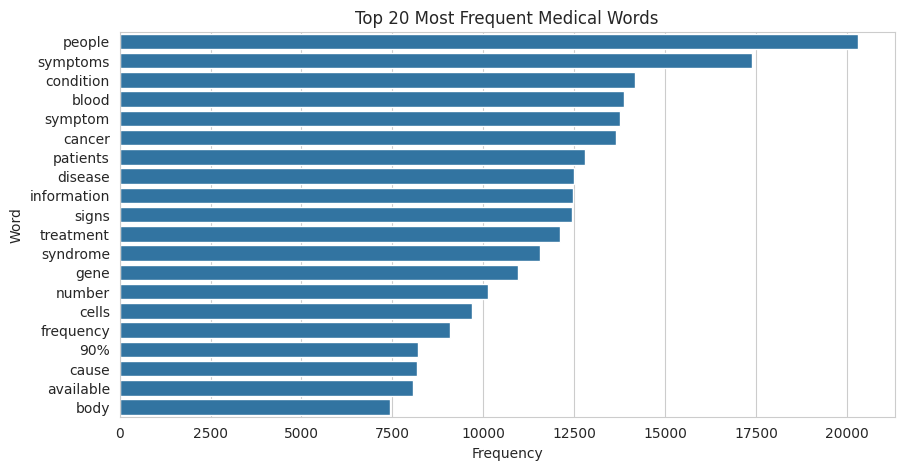

,Word,Frequency
0,people,20295
1,symptoms,17396
2,condition,14175
3,blood,13876
4,symptom,13770
5,cancer,13647
6,patients,12782
7,disease,12481
8,information,12479
9,signs,12443


In [16]:
# -----------------------------
# Most Common Words
# -----------------------------

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop = set(ENGLISH_STOP_WORDS)

words = []

for sentence in df["answer"].astype(str):
    for w in sentence.lower().split():
        w = w.strip(".,!?()[]{};:\"'")
        if len(w)>2 and w not in stop:
            words.append(w)

common = Counter(words).most_common(20)

common_df = pd.DataFrame(common,
                         columns=["Word","Frequency"])

plt.figure(figsize=(10,5))
sns.barplot(
    data=common_df,
    x="Frequency",
    y="Word"
)
plt.title("Top 20 Most Frequent Medical Words")
plt.show()

display(common_df)

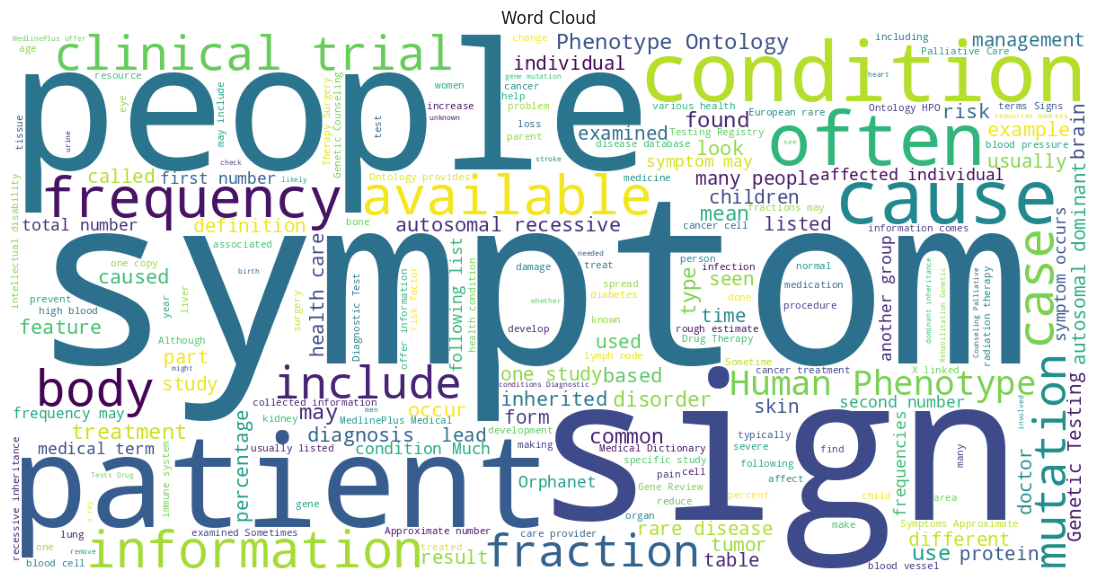

In [17]:
# -----------------------------
# WordCloud
# -----------------------------

text = " ".join(df["answer"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [18]:
# Normalize column names (MedQuAD CSVs in the wild use slightly different casings/names)
cols_lower = {c.lower().strip(): c for c in df.columns}

def find_col(*candidates):
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]
    return None

q_col = find_col("question", "questions")
a_col = find_col("answer", "answers")

if q_col is None or a_col is None:
    raise ValueError(
        f"Couldn't find Question/Answer columns among {list(df.columns)}. "
        "Please rename the relevant columns to 'Question' and 'Answer' in medquad.csv."
    )

qa_df = df[[q_col, a_col]].dropna()
qa_df.columns = ["question", "answer"]
qa_df["question"] = qa_df["question"].astype(str).str.strip()
qa_df["answer"] = qa_df["answer"].astype(str).str.strip()
qa_df = qa_df[(qa_df["question"] != "") & (qa_df["answer"] != "")]
qa_df = qa_df.drop_duplicates(subset=["question"]).reset_index(drop=True)

# Keep the corpus a Colab-friendly size; raise this if you have a GPU and want more coverage
MAX_ROWS = 500
qa_df = qa_df.head(MAX_ROWS)

questions = qa_df["question"].tolist()
answers = qa_df["answer"].tolist()
corpus = [f"Question: {q} Answer: {a}" for q, a in zip(questions, answers)]

print(f"Using {len(qa_df)} MedQuAD Q/A pairs as the retrieval corpus")
print("\nExample pair:\n")
print("Q:", questions[0])
print("A:", answers[0][:400], "...")

Using 500 MedQuAD Q/A pairs as the retrieval corpus

Example pair:

Q: What is (are) Glaucoma ?
A: Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is much greater for people over 60. How Glaucoma Develops  There are several different types of glaucoma. Most of these involve the drainage system within the eye. At the front of the eye there is a small space called the anterior chamber. A clea ...


## Step 4 — Baseline Retriever: raw PubMedBERT embeddings

We embed each MedQuAD question by mean-pooling `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext`'s last-layer token outputs. PubMedBERT was pretrained from scratch on PubMed abstracts and PubMed Central full text, so its vocabulary and representations are tuned for biomedical language — a much better starting point for medical text than generic `bert-base-uncased`.

Note: like raw BERT, PubMedBERT was pretrained with masked-language-modeling, **not** specifically for sentence-similarity search. It still works reasonably well here since the corpus is biomedical, but Part 2 swaps in a retrieval-tuned biomedical embedding model for a further boost.

In [19]:
BERT_MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(device)
bert_model.eval()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    summed = torch.sum(token_embeddings * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

@torch.no_grad()
def embed_texts_bert(texts, batch_size=16, max_length=256):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = bert_tokenizer(
            batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
        ).to(device)
        output = bert_model(**inputs)
        pooled = mean_pooling(output, inputs["attention_mask"])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        all_embeddings.append(pooled.cpu().numpy())
    return np.vstack(all_embeddings)

print("PubMedBERT retriever loaded:", BERT_MODEL_NAME)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PubMedBERT retriever loaded: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext


## Step 5 — Embed the corpus and build a baseline FAISS index

We embed the **questions** (that's what a user's query will be matched against) and keep the paired answers alongside for use as retrieved context.

In [20]:
question_embeddings = embed_texts_bert(questions)

dimension = question_embeddings.shape[1]
index_bert = faiss.IndexFlatIP(dimension)
index_bert.add(question_embeddings.astype("float32"))
print(f"Baseline PubMedBERT index: {index_bert.ntotal} vectors, dim {dimension}")

def retrieve_bert(query, top_k=3):
    query_vec = embed_texts_bert([query]).astype("float32")
    scores, idxs = index_bert.search(query_vec, top_k)
    return [(corpus[i], float(s)) for i, s in zip(idxs[0], scores[0])]

# Quick sanity check
for passage, score in retrieve_bert("What is glaucoma?", top_k=2):
    print(f"[{score:.3f}] {passage[:200]}...")

Baseline PubMedBERT index: 500 vectors, dim 768
[0.987] Question: What causes Glaucoma ? Answer: Nearly 2.7 million people have glaucoma, a leading cause of blindness in the United States. Although anyone can get glaucoma, some people are at higher risk. T...
[0.985] Question: What is (are) Glaucoma ? Answer: Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is ...


## Step 6 — Baseline Generator: `gpt2`

An open, general-purpose causal language model. No API key, runs locally. GPT-2 has no dedicated pad token, so we reuse its end-of-text token for padding.

In [21]:
GEN_MODEL_NAME = "gpt2"
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)
gen_tokenizer.pad_token = gen_tokenizer.eos_token

gen_model = AutoModelForCausalLM.from_pretrained(GEN_MODEL_NAME).to(device)
gen_model.eval()
print("Generator loaded:", GEN_MODEL_NAME)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Generator loaded: gpt2


## Step 7 — Baseline RAG pipeline

Retrieve (PubMedBERT + FAISS) → Augment (build prompt) → Generate (GPT-2).

Because GPT-2 is a *causal* LM, it generates a continuation of the prompt rather than a separate output sequence, so `generate_answer` slices off the prompt tokens and decodes only the newly generated ones.

In [22]:
def build_prompt(query, retrieved_passages, max_context_chars=1200):
    context_block = "\n\n".join(
        f"Passage {i+1}: {p}" for i, (p, _) in enumerate(retrieved_passages)
    )
    context_block = context_block[:max_context_chars]
    return (
        "Answer the medical question using ONLY the context below. "
        "If the answer is not in the context, say 'I don't know'.\n\n"
        f"Context:\n{context_block}\n\n"
        f"Question: {query}\nAnswer:"
    )

@torch.no_grad()
def generate_answer(prompt, model, tokenizer, max_new_tokens=80):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=900).to(device)
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        num_beams=4,
        no_repeat_ngram_size=3,
        pad_token_id=tokenizer.eos_token_id,
    )
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def rag_answer_baseline(query, top_k=3, max_new_tokens=80):
    retrieved = retrieve_bert(query, top_k=top_k)
    prompt = build_prompt(query, retrieved)
    answer = generate_answer(prompt, gen_model, gen_tokenizer, max_new_tokens=max_new_tokens)
    return answer, retrieved

test_questions = [
    questions[0],
    "What are the symptoms of diabetes?",
    "How is high blood pressure treated?",
]

for q in test_questions:
    answer, retrieved = rag_answer_baseline(q)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print(f"(top retrieved: {retrieved[0][0][:120]}...)")
    print("-" * 80)

Q: What is (are) Glaucoma ?
A: There are two main types of open-glaucomas. The first type is called glaucona. This type is caused by a buildup of fluid in the corneal cavity. This buildup can lead to vision loss or blindness. The second type is known as glaucoidosis. This is a condition in which the fluid in a cornea or iris gets trapped in the
(top retrieved: Question: What is (are) Glaucoma ? Answer: Glaucoma is a group of diseases that can damage the eye's optic nerve and res...)
--------------------------------------------------------------------------------
Q: What are the symptoms of diabetes?
A: Type 1 diabetes is a type of diabetes that is caused by a genetic mutation that causes the pancreas to produce insulin. Type 2 diabetes is also known as Type 2 Diabetes.

Type 1 diabetes can be caused by mutations in the genes responsible for the production of insulin. These mutations cause the body to produce more insulin than it needs to. The body can't produce enough insulin to meet t

---
# Part 2 — Upgrading every stage of the pipeline

Each upgrade below is a drop-in replacement for one piece of the baseline. They're built incrementally so you can mix and match.

## Step 8 — Upgrade 1: A retrieval-tuned biomedical encoder (`NeuML/pubmedbert-base-embeddings`)

`NeuML/pubmedbert-base-embeddings` starts from PubMedBERT but is further fine-tuned with `sentence-transformers` specifically for semantic similarity/retrieval, so semantically similar medical sentences land close together in vector space — the same idea as `all-MiniLM-L6-v2` in a general-domain RAG pipeline, but tuned for biomedical text.

We embed the same MedQuAD questions with it and build a second FAISS index so we can compare against the baseline.

In [23]:
retriever_v2 = SentenceTransformer("NeuML/pubmedbert-base-embeddings", device=device)

question_embeddings_v2 = retriever_v2.encode(
    questions, batch_size=32, normalize_embeddings=True, show_progress_bar=True
)

dimension_v2 = question_embeddings_v2.shape[1]
index_v2 = faiss.IndexFlatIP(dimension_v2)
index_v2.add(question_embeddings_v2.astype("float32"))
print(f"Retrieval-tuned PubMedBERT index: {index_v2.ntotal} vectors, dim {dimension_v2}")

def retrieve_v2(query, top_k=3, index=index_v2, texts=corpus):
    query_vec = retriever_v2.encode([query], normalize_embeddings=True).astype("float32")
    scores, idxs = index.search(query_vec, top_k)
    return [(texts[i], float(s)) for i, s in zip(idxs[0], scores[0])]

for passage, score in retrieve_v2("What is glaucoma?", top_k=2):
    print(f"[{score:.3f}] {passage[:200]}...")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.33k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Retrieval-tuned PubMedBERT index: 500 vectors, dim 768
[0.939] Question: What is (are) Glaucoma ? Answer: Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is ...
[0.804] Question: What is (are) Cataract ? Answer: A Clouding of the Lens in the Eye A cataract is a clouding of the lens in the eye that affects vision. The lens is a clear part of the eye that helps to focu...


## Step 9 — Upgrade 2: Chunk long answers before embedding

Some MedQuAD answers are long and cover several sub-topics — embedding the whole answer into one vector blurs its meaning. Splitting long answers into smaller overlapping **chunks** before embedding gives each vector a sharper, more specific meaning, so retrieval finds the exact relevant piece instead of a whole loosely-related answer.

We chunk by words with a small overlap so we don't cut a sentence's context off mid-thought at a chunk boundary, and we keep the originating question attached to each chunk for readability.

In [24]:
def chunk_text(text, chunk_size=60, overlap=15):
    # Split text into overlapping word-based chunks.
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunks.append(" ".join(words[start:end]))
        start += chunk_size - overlap
    return chunks or [text]

chunked_corpus = []
for question, answer in zip(questions, answers):
    for piece in chunk_text(answer):
        chunked_corpus.append(f"Question: {question} Answer (excerpt): {piece}")

print(f"{len(qa_df)} Q/A pairs -> {len(chunked_corpus)} chunks")
print("\nExample chunk:\n")
print(chunked_corpus[0][:400], "...")

chunk_embeddings = retriever_v2.encode(
    chunked_corpus, batch_size=32, normalize_embeddings=True, show_progress_bar=True
)

dimension_chunks = chunk_embeddings.shape[1]
index_chunks = faiss.IndexFlatIP(dimension_chunks)
index_chunks.add(chunk_embeddings.astype("float32"))
print(f"Chunked index: {index_chunks.ntotal} vectors, dim {dimension_chunks}")

500 Q/A pairs -> 5555 chunks

Example chunk:

Question: What is (are) Glaucoma ? Answer (excerpt): Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is much greater for people over 60. How Glaucoma Develops There are several different types of glaucoma. Most of these involve the drainage system within the eye. At the front of the eye ...


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

Chunked index: 5555 vectors, dim 768


## Step 10 — Upgrade 3: Cross-encoder re-ranking

Bi-encoders (PubMedBERT variants) embed the query and each passage **separately**, so search is fast but approximate. A **cross-encoder** instead reads the query and a passage *together* in one pass, letting it directly compare them word-for-word — far more accurate, but too slow to run on the whole corpus.

The standard fix: use the fast bi-encoder to fetch a wider pool of candidates (e.g. top 10), then re-score just those with the cross-encoder and keep the best few.

In [25]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=device)

def retrieve_and_rerank(query, index=index_chunks, texts=chunked_corpus,
                         candidate_k=10, final_k=3):
    # 1) fast, approximate candidate retrieval
    candidates = retrieve_v2(query, top_k=candidate_k, index=index, texts=texts)
    candidate_texts = [c[0] for c in candidates]

    # 2) accurate re-scoring with the cross-encoder
    pairs = [[query, text] for text in candidate_texts]
    rerank_scores = reranker.predict(pairs)

    reranked = sorted(zip(candidate_texts, rerank_scores), key=lambda x: x[1], reverse=True)
    return reranked[:final_k]

for passage, score in retrieve_and_rerank("What are the symptoms of diabetes?"):
    print(f"[{score:.3f}] {passage[:200]}...")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[9.886] Question: What are the symptoms of Diabetes ? Answer (excerpt): it, according to 2012 estimates by the Centers for Disease Control and Prevention (CDC). Common Signs Some common symptoms of diabetes a...
[9.153] Question: What are the symptoms of Diabetes ? Answer (excerpt): slowly - having dry, itchy skin - loss of feeling or tingling in the feet - having blurry eyesight. being very thirsty frequent urinatio...
[8.105] Question: What is (are) Diabetes ? Answer (excerpt): moderate physical activity, you can delay or prevent type 2 diabetes. Learn more about prediabetes here. Signs of Diabetes Many people with diabete...


## Step 11 — Upgrade 4: A scalable FAISS index (`IndexIVFFlat`)

`IndexFlatIP` compares a query against **every** vector — exact, but linear in corpus size, so it stops scaling once you have millions of passages (the full MedQuAD dataset alone has ~47K Q/A pairs, and real deployments often index far more). `IndexIVFFlat` first clusters all vectors into `nlist` groups (via k-means), and at search time only scans the handful of clusters closest to the query. That trades a small amount of accuracy for a large speedup, which is what production vector databases (Chroma, Weaviate, Pinecone) do under the hood.

In [26]:
embeddings_for_ivf = chunk_embeddings.astype("float32")
dimension_ivf = embeddings_for_ivf.shape[1]

nlist = min(50, max(1, len(chunked_corpus) // 20))  # rule of thumb: a few dozen vectors per cluster
quantizer = faiss.IndexFlatIP(dimension_ivf)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension_ivf, nlist, faiss.METRIC_INNER_PRODUCT)

index_ivf.train(embeddings_for_ivf)      # k-means clustering step, required before adding vectors
index_ivf.add(embeddings_for_ivf)
index_ivf.nprobe = 5                     # how many clusters to scan at search time

print(f"IVF index: {index_ivf.ntotal} vectors, {nlist} clusters, nprobe={index_ivf.nprobe}")

def retrieve_ivf(query, top_k=3):
    query_vec = retriever_v2.encode([query], normalize_embeddings=True).astype("float32")
    scores, idxs = index_ivf.search(query_vec, top_k)
    return [(chunked_corpus[i], float(s)) for i, s in zip(idxs[0], scores[0]) if i != -1]

for passage, score in retrieve_ivf("How is high blood pressure treated?"):
    print(f"[{score:.3f}] {passage[:200]}...")

IVF index: 5555 vectors, 50 clusters, nprobe=5
[0.758] Question: How to diagnose High Blood Pressure ? Answer (excerpt): Is my systolic pressure too high (over 140)? Your Blood Pressure Numbers - What is my blood pressure reading in numbers? - What is my ...
[0.755] Question: What are the symptoms of High Blood Pressure ? Answer (excerpt): a table at the level of your heart. After a Diagnosis If you're diagnosed with high blood pressure, your doctor will prescrib...
[0.754] Question: What are the treatments for High Blood Pressure ? Answer (excerpt): High blood pressure is treated with lifestyle changes and medicines. Treatment can help control blood pressure, but it wil...


## Step 12 — Upgrade 5: A larger generator (`gpt2-medium`)

Bigger GPT-2 checkpoints follow the retrieved context more reliably and produce more fluent answers, at the cost of more GPU memory and slower inference. `gpt2-medium` (~355M params) is still fully open and Colab-friendly.

For a further step up in answer quality, swap in an **instruction-tuned** open model instead — e.g. `google/flan-t5-base` (seq2seq) or `mistralai/Mistral-7B-Instruct-v0.2` (load in 4-bit with `bitsandbytes` on a T4). Those follow "answer using only this context" instructions far better than base GPT-2, which was never trained to follow instructions.

In [27]:
LARGE_GEN_MODEL_NAME = "gpt2-medium"
large_gen_tokenizer = AutoTokenizer.from_pretrained(LARGE_GEN_MODEL_NAME)
large_gen_tokenizer.pad_token = large_gen_tokenizer.eos_token

large_gen_model = AutoModelForCausalLM.from_pretrained(LARGE_GEN_MODEL_NAME).to(device)
large_gen_model.eval()
print("Loaded upgraded generator:", LARGE_GEN_MODEL_NAME)

# --- Optional: an instruction-tuned open model instead (uncomment to use) ---
# from transformers import AutoModelForSeq2SeqLM
# large_gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
# large_gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to(device)
# large_gen_model.eval()

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.52GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded upgraded generator: gpt2-medium


## Step 13 — The fully upgraded RAG pipeline

Chunked MedQuAD corpus → retrieval-tuned PubMedBERT + FAISS candidate retrieval → cross-encoder re-ranking → `gpt2-medium` generation.

In [28]:
def rag_answer_upgraded(query, candidate_k=10, final_k=3, max_new_tokens=80):
    reranked = retrieve_and_rerank(query, candidate_k=candidate_k, final_k=final_k)
    prompt = build_prompt(query, reranked)
    answer = generate_answer(prompt, large_gen_model, large_gen_tokenizer, max_new_tokens=max_new_tokens)
    return answer, reranked

test_questions = [
    questions[0],
    "What are the symptoms of diabetes?",
    "How is high blood pressure treated?",
]

for q in test_questions:
    answer, reranked = rag_answer_upgraded(q)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print(f"(top re-ranked passage: {reranked[0][0][:120]}...)")
    print("-" * 80)

Q: What is (are) Glaucoma ?
A: (excerpt)

Glaucomas are the most common cause of vision loss in people over the age of 60. They occur when the pressure in the eye builds up too quickly and causes the fluid to flow too slowly. This causes the pressure to build up too much and cause the fluid in the open

passage to flow out too quickly. This can lead to damage
(top re-ranked passage: Question: What is (are) Glaucoma ? Answer (excerpt): Glaucoma is a group of diseases that can damage the eye's optic ner...)
--------------------------------------------------------------------------------
Q: What are the symptoms of diabetes?
A: (excerpt)

Common Signs

Some common signs of diabetes can be found here: http://www.cdc.gov/diabetes/diseases-disease-prevention/symptoms-diabetes.html

Symptoms of Type 1 Diabetes

Type 1 diabetes is the most common type of diabetes in the United States. Type 1 diabetes
(top re-ranked passage: Question: What are the symptoms of Diabetes ? Answer (excerpt): it, ac

In [ ]:
# =========================
# Professional RAG Inference
# =========================

def rag_answer_upgraded(query,
                        candidate_k=10,
                        final_k=3,
                        max_new_tokens=120):
    """
    Professional RAG inference pipeline
    """

    # Step 1: Retrieve + Cross-Encoder Re-rank
    reranked = retrieve_and_rerank(
        query,
        candidate_k=candidate_k,
        final_k=final_k
    )

    # Step 2: Build Prompt
    prompt = build_prompt(query, reranked)

    # Step 3: Generate Answer
    raw_answer = generate_answer(
        prompt,
        large_gen_model,
        large_gen_tokenizer,
        max_new_tokens=max_new_tokens
    )

    # Step 4: Clean Output
    answer = raw_answer.replace(prompt, "").strip()

    # Remove duplicate sentences
    sentences = []
    seen = set()

    for s in answer.split("."):
        s = s.strip()
        if len(s) > 5 and s.lower() not in seen:
            sentences.append(s)
            seen.add(s.lower())

    answer = ". ".join(sentences)

    if len(answer) > 0:
        answer += "."

    # Step 5: Handle Empty Answers
    if len(answer) < 15:
        answer = (
            "I couldn't find enough reliable information in the retrieved "
            "medical documents to answer this question."
        )

    return {
        "query": query,
        "answer": answer,
        "evidence": reranked
    }


# =========================
# Example Questions
# =========================

test_questions = [
    questions[0],
    "What are the symptoms of diabetes?",
    "How is high blood pressure treated?",
]


# =========================
# Display Results
# =========================

for i, q in enumerate(test_questions, 1):

    result = rag_answer_upgraded(q)

    print("=" * 100)
    print(f"Question {i}")
    print("=" * 100)

    print(f"\nQuestion:\n{result['query']}\n")

    print("Answer:")
    print(result["answer"])

    print("\nTop Retrieved Evidence:")

    for rank, (text, score) in enumerate(result["evidence"], 1):

        snippet = text.replace("\n", " ")[:180]

        print(f"\n[{rank}] Similarity Score: {score:.4f}")
        print(snippet + "...")

print("\nEvaluation Complete.")

## Step 14 — Summary: baseline vs. upgraded

| Stage | Baseline (Part 1) | Upgraded (Part 2) |
|---|---|---|
| Data | MedQuAD, loaded from `medquad.csv` | Same, chunked at the answer level |
| Encoder | `PubMedBERT` (mean-pooled, not retrieval-tuned) | `NeuML/pubmedbert-base-embeddings` (contrastively trained for semantic similarity) |
| Granularity | Whole Q/A pairs | Overlapping word-level chunks of each answer |
| Search | Exact `IndexFlatIP` | Also shown: clustered `IndexIVFFlat` for scale |
| Precision | Bi-encoder score only | Bi-encoder candidates + cross-encoder re-ranking |
| Generator | `gpt2` (~124M params) | `gpt2-medium` (~355M params), with a note on swapping in an instruction-tuned model |

**Where to go from here:**
- Use the full MedQuAD CSV (raise `MAX_ROWS` in Step 3) once you're happy with retrieval quality on the smaller sample.
- Swap `gpt2-medium` for an instruction-tuned open model (`flan-t5-base/large`, `Mistral-7B-Instruct`, `Llama-3-8B-Instruct`) for noticeably better-behaved, on-topic answers.
- This pipeline is for **educational/demo purposes only** and is not a substitute for professional medical advice.

In [ ]:
# ==========================================================
# Gradio Interface for Professional Medical RAG System
# Compatible with rag_answer_upgraded() returning a dictionary
# ==========================================================

!pip -q install -U gradio

import traceback
import pandas as pd
import gradio as gr


# ==========================================================
# Prediction Function
# ==========================================================

def medical_chat(
    question,
    candidate_k=10,
    final_k=3,
    max_tokens=120
):

    if not question.strip():
        return (
            "⚠️ Please enter a medical question.",
            pd.DataFrame()
        )

    try:

        # -------------------------------
        # Professional RAG Inference
        # -------------------------------
        result = rag_answer_upgraded(
            query=question,
            candidate_k=int(candidate_k),
            final_k=int(final_k),
            max_new_tokens=int(max_tokens)
        )

        answer = result.get("answer", "")
        evidence = result.get("evidence", [])

        rows = []

        for idx, item in enumerate(evidence, start=1):

            # -------------------------------
            # Case 1 -> Tuple
            # (text, score)
            # -------------------------------
            if isinstance(item, tuple):

                if len(item) == 2:

                    text, score = item

                    rows.append({
                        "Rank": idx,
                        "Similarity Score": round(float(score), 4),
                        "Retrieved Context": str(text)[:500]
                    })

                else:

                    rows.append({
                        "Rank": idx,
                        "Similarity Score": "",
                        "Retrieved Context": str(item)[:500]
                    })

            # -------------------------------
            # Case 2 -> Dictionary
            # -------------------------------
            elif isinstance(item, dict):

                rows.append({
                    "Rank": idx,
                    "Similarity Score": round(
                        float(item.get("score", 0)),
                        4
                    ),
                    "Retrieved Context": item.get(
                        "text",
                        ""
                    )[:500]
                })

            # -------------------------------
            # Case 3 -> String
            # -------------------------------
            else:

                rows.append({
                    "Rank": idx,
                    "Similarity Score": "",
                    "Retrieved Context": str(item)[:500]
                })

        df = pd.DataFrame(rows)

        return answer, df

    except Exception:

        error = traceback.format_exc()

        print(error)

        return (
            f"❌ Error\n\n{error}",
            pd.DataFrame()
        )


# ==========================================================
# Example Questions
# ==========================================================

examples = [

    ["What is breast cancer?"],

    ["What are the symptoms of diabetes?"],

    ["How is lung cancer treated?"],

    ["What causes high blood pressure?"],

    ["What are the symptoms of leukemia?"],

    ["Can asthma be cured?"],

    ["What is liver cancer?"],

    ["What causes migraine headaches?"],

]


# ==========================================================
# Gradio UI
# ==========================================================

with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Medical RAG Assistant"
) as demo:

    gr.Markdown(
        """
# 🩺 Medical RAG Assistant

### Retrieval-Augmented Generation (RAG)

**Pipeline**

✅ PubMedBERT Embeddings

✅ Cross-Encoder Re-ranking

✅ GPT-2 Medium Generator

✅ MedQuAD Knowledge Base

Enter a consumer healthcare question below.
"""
    )

    with gr.Row():

        with gr.Column(scale=3):

            question = gr.Textbox(

                label="Medical Question",

                placeholder="Example: What are the symptoms of breast cancer?",

                lines=4

            )

            candidate_k = gr.Slider(

                minimum=5,

                maximum=30,

                value=10,

                step=1,

                label="Candidate Documents"

            )

            final_k = gr.Slider(

                minimum=1,

                maximum=10,

                value=3,

                step=1,

                label="Final Retrieved Documents"

            )

            max_tokens = gr.Slider(

                minimum=50,

                maximum=256,

                value=120,

                step=10,

                label="Maximum Generated Tokens"

            )

            submit = gr.Button(
                "Generate Answer",
                variant="primary"
            )

        with gr.Column(scale=4):

            answer = gr.Markdown(
                label="Generated Answer"
            )

    retrieved = gr.Dataframe(

        headers=[
            "Rank",
            "Similarity Score",
            "Retrieved Context"
        ],

        datatype=[
            "number",
            "number",
            "str"
        ],

        interactive=False,

        wrap=True,

        label="Retrieved Evidence"

    )

    submit.click(

        fn=medical_chat,

        inputs=[
            question,
            candidate_k,
            final_k,
            max_tokens
        ],

        outputs=[
            answer,
            retrieved
        ]

    )

    gr.Examples(

        examples=examples,

        inputs=question

    )

demo.launch(
    share=True,
    debug=True
)

In [ ]:
examples = [
    ["What is breast cancer?"],
    ["What are the symptoms of diabetes?"],
    ["How is lung cancer treated?"],
    ["What causes high blood pressure?"],
    ["What are the symptoms of leukemia?"],
    ["What is Alzheimer's disease?"],
    ["How can asthma be managed?"],
    ["What are the warning signs of a heart attack?"],
    ["What causes migraine headaches?"],
    ["How is kidney disease diagnosed?"],
    ["What are the symptoms of thyroid disorders?"],
    ["How can osteoporosis be prevented?"],
    ["What is hepatitis?"],
    ["How does hepatitis spread?"],
    ["What are the treatment options for Parkinson's disease?"],
    ["What causes anemia?"],
    ["What are the symptoms of pneumonia?"],
    ["How is rheumatoid arthritis treated?"],
    ["What are the risk factors for stroke?"],
    ["What are the symptoms of colon cancer?"],
    ["How can obesity affect overall health?"],
    ["What is chronic kidney disease?"],
    ["What causes stomach ulcers?"],
    ["What are the symptoms of liver disease?"],
    ["How is skin cancer diagnosed?"],
    ["What is multiple sclerosis?"],
    ["How is epilepsy treated?"],
    ["What causes chronic back pain?"],
    ["What are the symptoms of dengue fever?"],
    ["How can I lower my cholesterol naturally?"],
    ["What is the difference between Type 1 and Type 2 diabetes?"],
    ["What are the symptoms of COVID-19?"],
    ["How can influenza be prevented?"],
    ["What causes food allergies?"],
    ["What are the symptoms of celiac disease?"],
    ["How is tuberculosis treated?"],
    ["What causes kidney stones?"],
    ["What are the symptoms of appendicitis?"],
    ["How is psoriasis managed?"],
    ["What causes urinary tract infections?"],
    ["What are the symptoms of glaucoma?"],
    ["How is cataract surgery performed?"],
    ["What causes insomnia?"],
    ["What are the symptoms of anxiety disorders?"],
    ["How is depression treated?"],
    ["What causes osteoporosis?"],
    ["What are the symptoms of pancreatic cancer?"],
    ["How can heart disease be prevented?"],
    ["What are the early signs of Alzheimer's disease?"],
    ["What lifestyle changes help control high blood pressure?"]
]